# Does Visualization Style Only Distract Beginners?
## Expertise as a Moderator of the Split-Attention Effect

---

**Research Question:** Does the effect of visualization style (Galles vs. Metal) on pseudocode/map attention ratio depend on programming experience — do novices show a larger attention shift away from pseudocode in Metal than experts do?

**Groups:** Group 1 = Beginner · Group 2 = Intermediate · Group 3 = Advanced

In [1]:
import pandas as pd
import numpy as np
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

alt.data_transformers.disable_max_rows()
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120})
DATA_DIR = Path('../../')

EXPERIENCE_MAP = {'Group1': 'Beginner', 'Group2': 'Intermediate', 'Group3': 'Advanced'}
EXPERIENCE_ORDER = ['Beginner', 'Intermediate', 'Advanced']

---

## 1. Load Eye-Tracking Data

In [2]:
FILE_MAP = {
    'Group1_gallesBFSData.xls': ('Group1', 'Galles', 'BFS'),
    'Group1_gallesDFSData.xls': ('Group1', 'Galles', 'DFS'),
    'Group1_metalBFSData.xls':  ('Group1', 'Metal',  'BFS'),
    'Group1_metalDFSData.xls':  ('Group1', 'Metal',  'DFS'),
    'Group2_gallesBFSData.xls': ('Group2', 'Galles', 'BFS'),
    'Group2_gallesDFSData.xls': ('Group2', 'Galles', 'DFS'),
    'Group2_metalBFSData.xls':  ('Group2', 'Metal',  'BFS'),
    'Group2_metalDFSData.xls':  ('Group2', 'Metal',  'DFS'),
    'Group3_gallesBFSData.xls': ('Group3', 'Galles', 'BFS'),
    'Group3_gallesDFSData.xls': ('Group3', 'Galles', 'DFS'),
    'Group3_metalBFSData.xls':  ('Group3', 'Metal',  'BFS'),
    'Group3_metalDFSData.xls':  ('Group3', 'Metal',  'DFS'),
}
STAT_KW = {'nan', 'mean', 'sum', 'std', 'median', ''}

def get_col(df, metric, kw):
    return next((c for c in df.columns if metric in c and kw.lower() in c.lower()
                 and c.endswith('_Mean') and 'Include Zeros' not in c), None)

records = []
for fname, (grp, vis, algo) in FILE_MAP.items():
    p = DATA_DIR / fname
    if not p.exists(): continue
    raw = pd.read_excel(p, engine='xlrd')
    raw = raw.rename(columns={raw.columns[0]: 'participant'})
    cols = {
        'tfd_pseudocode':  get_col(raw, 'Total Fixation Duration', 'rectangle'),
        'tfd_map':         get_col(raw, 'Total Fixation Duration', 'rectangle 2'),
        'ttff_pseudocode': get_col(raw, 'Time to First Fixation',  'rectangle'),
    }
    for _, row in raw.iterrows():
        pname = str(row.get('participant', '')).strip()
        if pname.lower() in STAT_KW: continue
        records.append({
            'participant': pname, 'group': grp, 'vis_style': vis, 'algorithm': algo,
            **{k: pd.to_numeric(row.get(v), errors='coerce') for k, v in cols.items()}
        })

df = pd.DataFrame(records)
df['experience'] = df['group'].map(EXPERIENCE_MAP)
df['experience'] = pd.Categorical(df['experience'], categories=EXPERIENCE_ORDER, ordered=True)
df['pseudo_map_ratio'] = df['tfd_pseudocode'] / (df['tfd_map'] + 1e-9)
df = df[df['pseudo_map_ratio'] < 25]

print(f'{len(df)} rows | {df["participant"].nunique()} participants')
df.groupby('experience')['participant'].nunique()

219 rows | 197 participants


experience
Beginner        63
Intermediate    71
Advanced        67
Name: participant, dtype: int64

---

## Chart 1 — Does the style gap close for experienced viewers?

Mean pseudocode/map ratio by visualization style and experience level; a shrinking Galles–Metal gap from Beginner to Advanced indicates that style only distracts less experienced participants.

In [3]:
(
    alt.Chart(df)
    .mark_bar()
    .encode(
        x=alt.X('vis_style:N', title=None, axis=alt.Axis(labelAngle=0)),
        y=alt.Y('mean(pseudo_map_ratio):Q', title='Mean Pseudocode/Map Ratio'),
        color=alt.Color('vis_style:N', scale=alt.Scale(scheme='tableau10'), legend=None),
        column=alt.Column('experience:N', title='Experience Level',
                          sort=EXPERIENCE_ORDER),
        tooltip=[
            alt.Tooltip('vis_style:N'),
            alt.Tooltip('mean(pseudo_map_ratio):Q', format='.2f', title='Mean ratio'),
            alt.Tooltip('count():Q', title='N'),
        ]
    )
    .properties(width=130, height=200,
                title='Chart 1. Mean Attention Ratio by Visualization Style × Experience Level')
)

alt.Chart(...)

## Chart 2 — Interaction: does experience moderate the style effect?

Group means connected by lines across experience levels, one line per visualization style; diverging lines indicate the style effect changes with expertise.

In [4]:
df_means = (
    df.groupby(['experience', 'vis_style'])['pseudo_map_ratio']
    .mean().reset_index(name='mean_ratio')
)

strip = (
    alt.Chart(df)
    .mark_circle(opacity=0.35, size=40)
    .encode(
        x=alt.X('experience:O', sort=EXPERIENCE_ORDER, title='Experience Level'),
        y=alt.Y('pseudo_map_ratio:Q', title='Pseudocode/Map Ratio'),
        color=alt.Color('vis_style:N', scale=alt.Scale(scheme='set1'), title='Style'),
    )
)

lines = (
    alt.Chart(df_means)
    .mark_line(point=True, strokeWidth=2.5)
    .encode(
        x=alt.X('experience:O', sort=EXPERIENCE_ORDER),
        y='mean_ratio:Q',
        color=alt.Color('vis_style:N', scale=alt.Scale(scheme='set1')),
        tooltip=['experience', 'vis_style', alt.Tooltip('mean_ratio:Q', format='.2f')]
    )
)

(strip + lines).properties(
    width=320, height=260,
    title='Chart 2. Interaction Plot — Visualization Style × Experience Level'
)

alt.LayerChart(...)

## Chart 3 — Time to first fixation on pseudocode by experience level

Time to first fixation (ms) on the pseudocode panel across experience levels and styles; a longer TTFF in Metal for beginners indicates the richer visualization captured their attention before they oriented to the code.

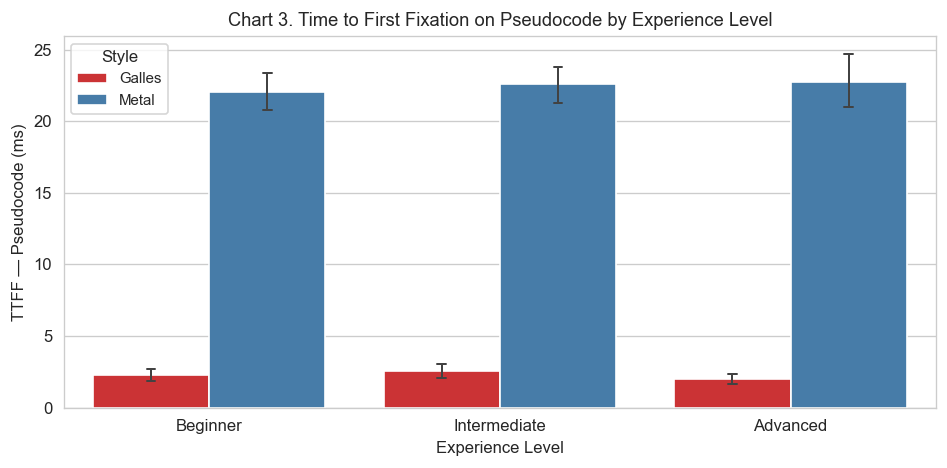

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=df.dropna(subset=['ttff_pseudocode']),
    x='experience', y='ttff_pseudocode', hue='vis_style',
    order=EXPERIENCE_ORDER,
    palette='Set1', ax=ax, errwidth=1.2, capsize=0.06
)
ax.set_title('Chart 3. Time to First Fixation on Pseudocode by Experience Level', fontsize=11)
ax.set_xlabel('Experience Level')
ax.set_ylabel('TTFF — Pseudocode (ms)')
ax.legend(title='Style', fontsize=9)
plt.tight_layout()
plt.show()